# -------------------------------------  EDA MASTER -------------------------------------

# Imports & display config

In [4]:

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import mannwhitneyu, ttest_ind, skew, pointbiserialr

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import MinMaxScaler

# Display settings
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore")

print("✅ Imports ready.")


✅ Imports ready.


# Load file & data (single workbook)

In [5]:
FILE_PATH = Path("MS_Capstone_Final_Quality_Check_Summary.xlsx")  
SHEET_CLEAN = "clean_data"

assert FILE_PATH.exists(), f"Workbook not found: {FILE_PATH}"

df = pd.read_excel(FILE_PATH, sheet_name=SHEET_CLEAN)

# Basic dtype fixes
date_cols = ["Result Date", "_T_date", "_T1_date", "_T2_date", "_T3_date"]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

num_cols = [
    "Sales","Expenses","Operating Profit","OPM %","Other Income","Interest",
    "Depreciation","Profit before tax","Tax %","Net Profit","EPS in Rs",
    "Revenue","Financing Profit","Financing Margin %",
    "Closing Price (T)","Closing Price (T+1)","Closing Price (T+2)","Closing Price (T+3)",
    "3-Day Avg Price Post Result","3-Day Return (%)","Movement Label (1,0)"
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

print("✅ Loaded:", FILE_PATH.name, "| sheet:", SHEET_CLEAN, "| shape:", df.shape)
display(df.head(10))


✅ Loaded: MS_Capstone_Final_Quality_Check_Summary.xlsx | sheet: clean_data | shape: (585, 32)


,Company,Ticker,AV_Ticker.BSE,Sector,Cap Category,Period,Sales,Expenses,Operating Profit,OPM %,Other Income,Interest,Depreciation,Profit before tax,Tax %,Net Profit,EPS in Rs,Result Date,Revenue,Financing Profit,Financing Margin %,_T_date,Closing Price (T),_T1_date,Closing Price (T+1),_T2_date,Closing Price (T+2),_T3_date,Closing Price (T+3),3-Day Avg Price Post Result,3-Day Return (%),"Movement Label (1,0)"
0,Tata Consultancy Services,TCS,TCS.BSE,IT / Technology,Large,Jun 2022,52758.0,39342.0,13416.0,25.0,789.0,199.0,1230.0,12776.0,25.0,9519.0,25.90,2022-07-08,NaN,NaN,NaN,2022-08-07,3265.45,2022-11-07,3113.80,2022-12-07,3084.70,2022-07-13,3038.75,3079.083333,-5.71,0.0
1,Tata Consultancy Services,TCS,TCS.BSE,IT / Technology,Large,Sep 2022,55309.0,40793.0,14516.0,26.0,965.0,148.0,1237.0,14096.0,26.0,10465.0,28.51,2022-10-10,NaN,NaN,NaN,2022-10-10,3118.55,2022-11-10,3069.55,2022-12-10,3100.75,2022-10-13,3103.30,3091.200000,-0.88,0.0
2,Tata Consultancy Services,TCS,TCS.BSE,IT / Technology,Large,Dec 2022,58229.0,42676.0,15553.0,27.0,520.0,160.0,1269.0,14644.0,26.0,10883.0,29.64,2023-01-09,NaN,NaN,NaN,2023-09-01,3319.95,2023-10-01,3286.40,2023-11-01,3328.70,2023-12-01,3334.35,3316.483333,-0.10,0.0
3,Tata Consultancy Services,TCS,TCS.BSE,IT / Technology,Large,Mar 2023,59162.0,43388.0,15774.0,27.0,1175.0,272.0,1286.0,15391.0,26.0,11436.0,31.13,2023-04-12,NaN,NaN,NaN,2023-12-04,3241.65,2023-04-13,3188.85,2023-04-17,3139.50,2023-04-18,3130.75,3153.033333,-2.73,0.0
4,Tata Consultancy Services,TCS,TCS.BSE,IT / Technology,Large,Jun 2023,59381.0,44383.0,14998.0,25.0,1397.0,163.0,1243.0,14989.0,26.0,11120.0,30.26,2023-07-12,NaN,NaN,NaN,2023-12-07,3259.90,2023-07-13,3340.55,2023-07-14,3514.65,2023-07-17,3491.70,3448.966667,5.80,1.0
5,Tata Consultancy Services,TCS,TCS.BSE,IT / Technology,Large,Sep 2023,59692.0,43946.0,15746.0,26.0,1006.0,159.0,1263.0,15330.0,26.0,11380.0,31.00,2023-10-11,NaN,NaN,NaN,2023-11-10,3609.90,2023-12-10,3542.55,2023-10-13,3570.85,2023-10-16,3524.05,3545.816667,-1.78,0.0
6,Tata Consultancy Services,TCS,TCS.BSE,IT / Technology,Large,Dec 2023,60583.0,44195.0,16388.0,27.0,-96.0,230.0,1233.0,14829.0,25.0,11097.0,30.56,2024-01-11,NaN,NaN,NaN,2024-11-01,3735.55,2024-12-01,3882.80,2024-01-15,3903.80,2024-01-16,3861.30,3882.633333,3.94,1.0
7,Tata Consultancy Services,TCS,TCS.BSE,IT / Technology,Large,Mar 2024,61237.0,44073.0,17164.0,28.0,1157.0,226.0,1246.0,16849.0,26.0,12502.0,34.37,2024-04-12,NaN,NaN,NaN,2024-12-04,4001.40,2024-04-15,3941.20,2024-04-16,3872.80,2024-04-18,3862.00,3892.000000,-2.73,0.0
8,Tata Consultancy Services,TCS,TCS.BSE,IT / Technology,Large,Jun 2024,62613.0,45951.0,16662.0,27.0,962.0,173.0,1220.0,16231.0,25.0,12105.0,33.28,2024-07-11,NaN,NaN,NaN,2024-07-11,3922.70,2024-07-12,4184.90,2024-07-15,4168.00,2024-07-16,4175.35,4176.083333,6.46,1.0
9,Tata Consultancy Services,TCS,TCS.BSE,IT / Technology,Large,Sep 2024,64259.0,47528.0,16731.0,26.0,729.0,162.0,1266.0,16032.0,25.0,11955.0,32.92,2024-10-10,NaN,NaN,NaN,2024-10-10,4227.40,2024-10-11,4149.20,2024-10-14,4136.65,2024-10-15,4116.80,4134.216667,-2.20,0.0


# Helpers: output folders, save figures & tables

In [6]:
OUTROOT = Path.cwd()

def _ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)

def cell_outdir(cell_no: int) -> Path:
    d = OUTROOT / f"cell_{cell_no}"
    _ensure_dir(d)
    return d

def save_fig(fig, cell_no: int, filename: str, dpi: int = 150):
    d = cell_outdir(cell_no)
    safe_name = filename.replace("/", "_").replace("\\", "_")
    path = d / safe_name
    fig.tight_layout()
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.show(fig)
    print(f"[saved] {path}")

def save_tables(cell_no: int, tables: dict, book_name: str = None):
    d = cell_outdir(cell_no)
    if book_name is None:
        book_name = f"tables_cell_{cell_no}.xlsx"
    path = d / book_name
    with pd.ExcelWriter(path, engine="xlsxwriter") as xw:
        for name, tbl in tables.items():
            # Handle Series gracefully
            if isinstance(tbl, pd.Series):
                tbl = tbl.to_frame().reset_index()
                tbl.columns = ["index", "value"]
            tbl.to_excel(xw, sheet_name=str(name)[:31], index=False)
    print(f"[saved] {path}")

print("✅ Helper functions ready.")


✅ Helper functions ready.


# Health checks (quick sanity from clean_data only)

In [7]:
cell_no = 4

essential = ["Company","Ticker","Sector","Cap Category","Result Date","_T_date",
             "Closing Price (T)","3-Day Return (%)","Movement Label (1,0)"]
present = [c for c in essential if c in df.columns]
missing = [c for c in essential if c not in df.columns]

shape_info = pd.DataFrame({"rows":[len(df)], "cols":[df.shape[1]]})
nulls = df[present].isna().sum().sort_values(ascending=False).rename("null_count").to_frame()
by_sector = df.groupby("Sector").size().rename("rows").to_frame() if "Sector" in df.columns else pd.DataFrame()
label_balance = df["Movement Label (1,0)"].value_counts(dropna=False).rename("count").to_frame() if "Movement Label (1,0)" in df.columns else pd.DataFrame()

print("Essential columns found:", present)
if missing:
    print("⚠️ Missing essential columns:", missing)

display(shape_info)
display(nulls.head(20))
display(by_sector)
display(label_balance)

save_tables(cell_no, {
    "shape_info": shape_info,
    "nulls_top20": nulls.head(20),
    "by_sector": by_sector.reset_index(),
    "label_balance": label_balance.reset_index()
})


Essential columns found: ['Company', 'Ticker', 'Sector', 'Cap Category', 'Result Date', '_T_date', 'Closing Price (T)', '3-Day Return (%)', 'Movement Label (1,0)']


,rows,cols
0,585,32


,null_count
"Movement Label (1,0)",1
Closing Price (T),1
3-Day Return (%),1
_T_date,1
Company,0
Result Date,0
Cap Category,0
Sector,0
Ticker,0


,rows
Sector,
Auto,117
BFSI,117
FMCG,117
IT / Technology,117
Pharma,117


,count
"Movement Label (1,0)",
0.0,344
1.0,240
NaN,1


[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_4\tables_cell_4.xlsx


# Price & label sanity (gaps, returns, label balance)

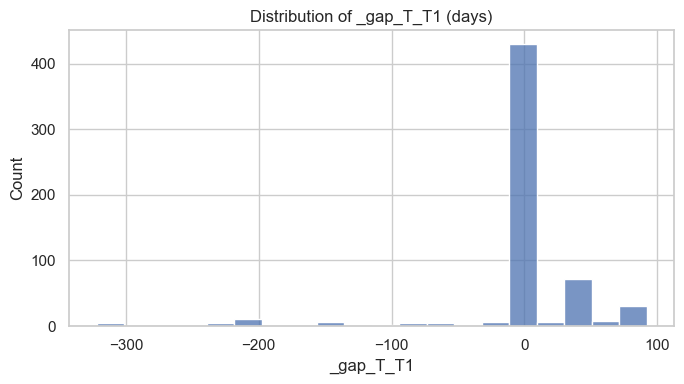

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_5\hist__gap_T_T1.png


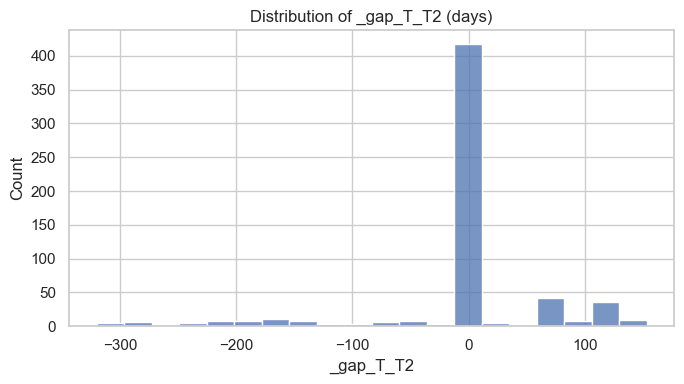

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_5\hist__gap_T_T2.png


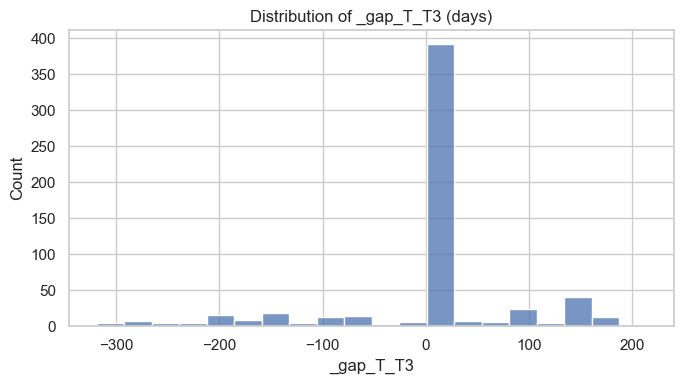

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_5\hist__gap_T_T3.png


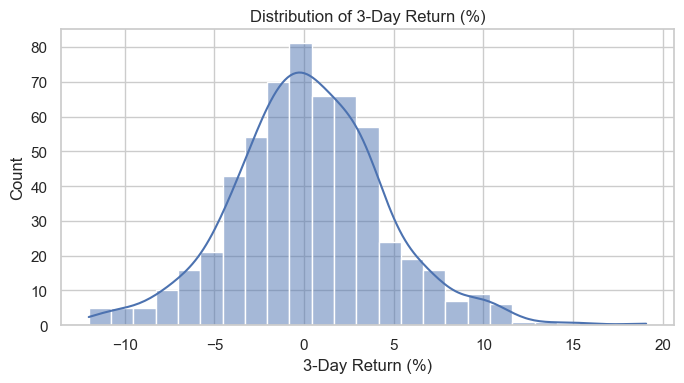

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_5\hist_3day_return.png


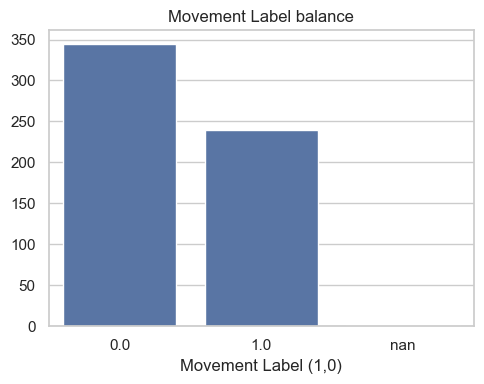

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_5\bar_movement_label.png


,Rows,Missing _T_date,Missing Closing Price (T),Return NaNs
0,585,1,1,1


[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_5\tables_cell_5.xlsx


In [8]:
cell_no = 5

# Date gaps between T and T+1/T+2/T+3 (calendar days)
def gap_days(a, b):
    if pd.isna(a) or pd.isna(b):
        return np.nan
    return (b - a).days

df["_gap_T_T1"] = df.apply(lambda r: gap_days(r.get("_T_date"), r.get("_T1_date")), axis=1)
df["_gap_T_T2"] = df.apply(lambda r: gap_days(r.get("_T_date"), r.get("_T2_date")), axis=1)
df["_gap_T_T3"] = df.apply(lambda r: gap_days(r.get("_T_date"), r.get("_T3_date")), axis=1)

# Histograms of gaps
for gcol in ["_gap_T_T1","_gap_T_T2","_gap_T_T3"]:
    if gcol in df.columns:
        fig, ax = plt.subplots(figsize=(7,4))
        sns.histplot(df[gcol].dropna(), bins=20, ax=ax)
        ax.set_title(f"Distribution of {gcol} (days)")
        save_fig(fig, cell_no, f"hist_{gcol}.png")

# Distribution of 3-Day Return (%)
if "3-Day Return (%)" in df.columns:
    fig, ax = plt.subplots(figsize=(7,4))
    sns.histplot(df["3-Day Return (%)"].dropna(), bins=25, ax=ax, kde=True)
    ax.set_title("Distribution of 3-Day Return (%)")
    save_fig(fig, cell_no, "hist_3day_return.png")

# Movement label balance
if "Movement Label (1,0)" in df.columns:
    fig, ax = plt.subplots(figsize=(5,4))
    lb = df["Movement Label (1,0)"].value_counts(dropna=False)
    sns.barplot(x=lb.index.astype(str), y=lb.values, ax=ax)
    ax.set_title("Movement Label balance")
    save_fig(fig, cell_no, "bar_movement_label.png")

summary = pd.DataFrame({
    "Rows":[len(df)],
    "Missing _T_date":[df["_T_date"].isna().sum()] if "_T_date" in df.columns else [np.nan],
    "Missing Closing Price (T)":[df["Closing Price (T)"].isna().sum()] if "Closing Price (T)" in df.columns else [np.nan],
    "Return NaNs":[df["3-Day Return (%)"].isna().sum()] if "3-Day Return (%)" in df.columns else [np.nan]
})
display(summary)
save_tables(cell_no, {"price_return_summary": summary})


# Feature distributions & Up/Down contrasts

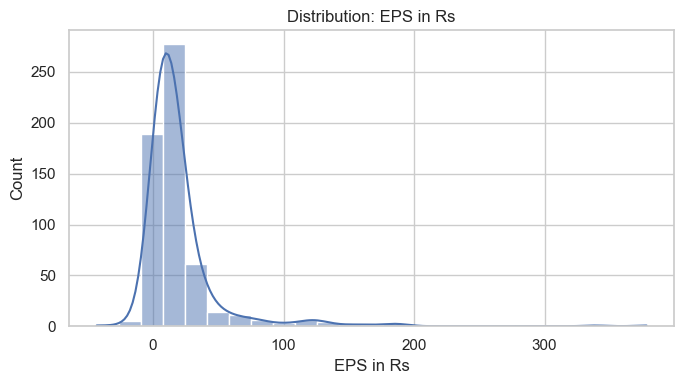

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_6\hist_EPS_in_Rs.png


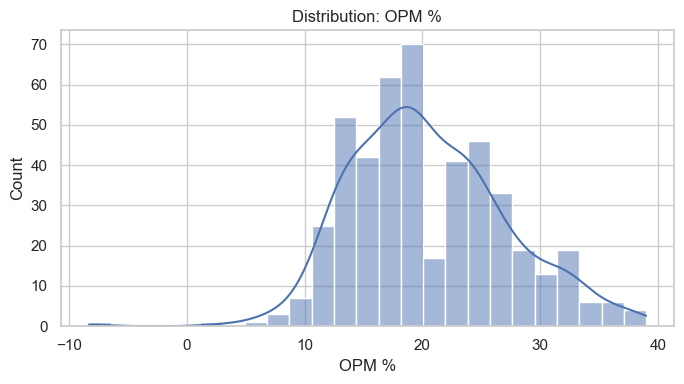

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_6\hist_OPM_pct.png


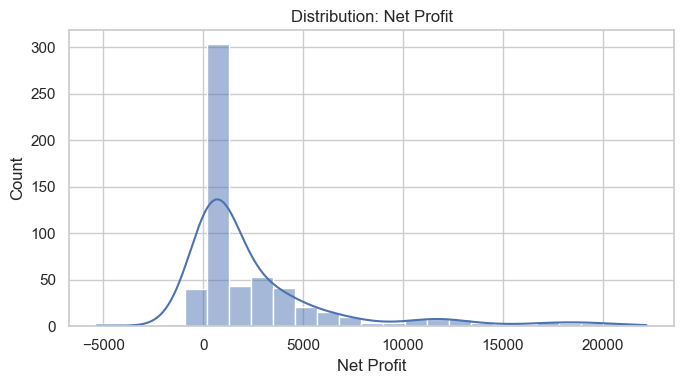

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_6\hist_Net_Profit.png


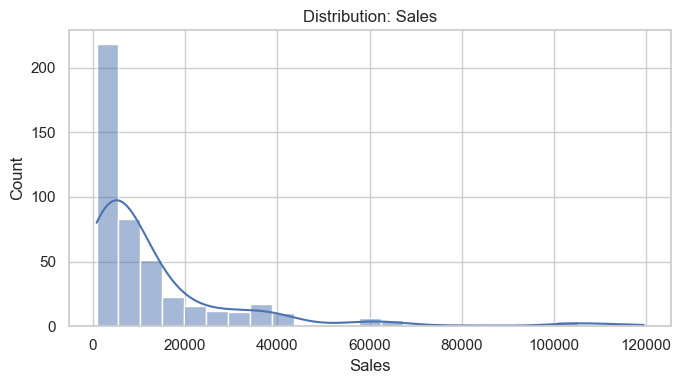

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_6\hist_Sales.png


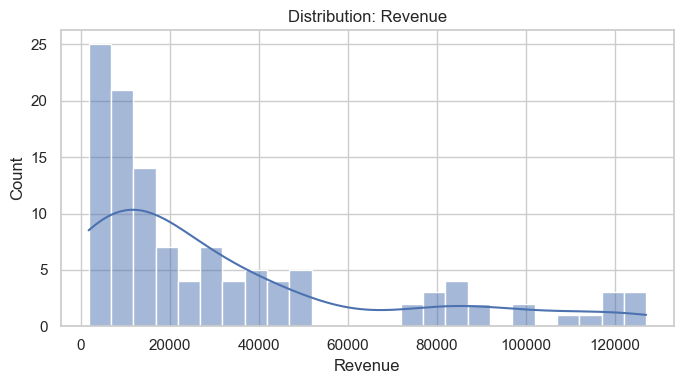

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_6\hist_Revenue.png


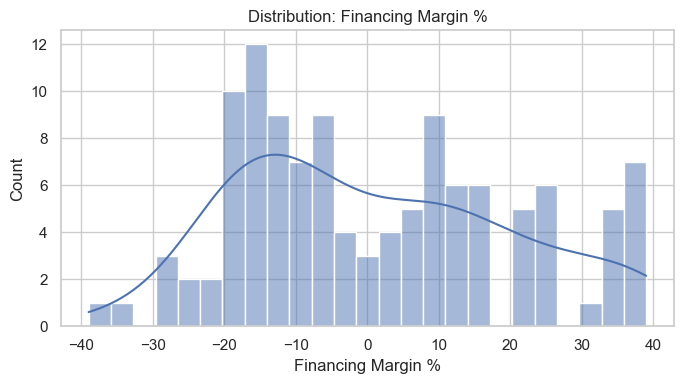

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_6\hist_Financing_Margin_pct.png


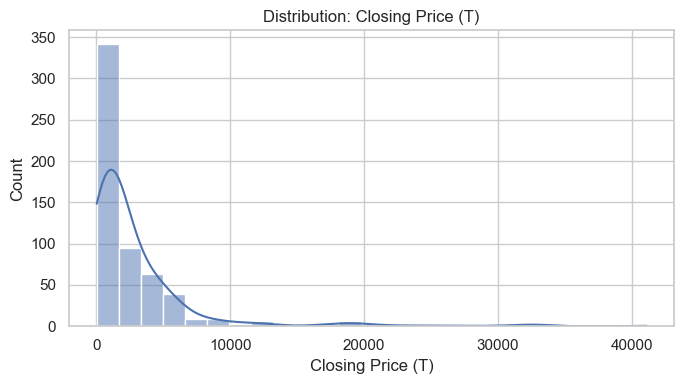

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_6\hist_Closing_Price_(T).png


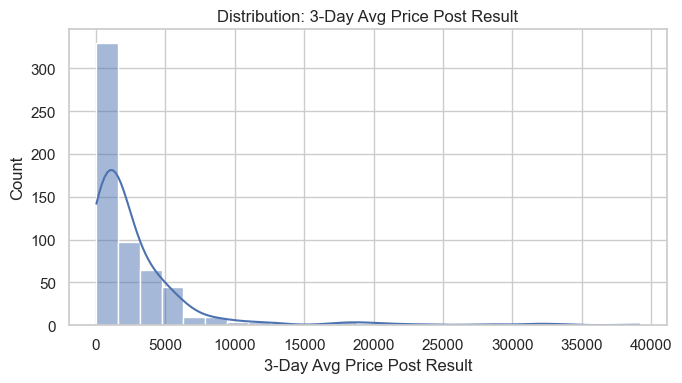

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_6\hist_3-Day_Avg_Price_Post_Result.png


,feature,mean_up,mean_down,median_up,median_down,cohen_d,cliffs_delta,t_test_p,mannwhitney_p
8,3-Day Return (%),4.206833,-2.436628,3.435000,-1.860000,2.407283,1.000000,2.804010e-106,4.493725e-94
1,OPM %,19.784577,21.019511,19.000000,20.000000,-0.188270,-0.096978,4.511819e-02,7.226466e-02
2,Net Profit,2353.132208,3044.392006,813.500000,1019.500000,-0.162659,-0.107449,4.770516e-02,2.705937e-02
6,Closing Price (T),2691.145083,3075.215349,1277.025000,1529.200000,-0.081932,-0.050642,3.114507e-01,2.975158e-01
0,EPS in Rs,18.956000,21.296599,13.050000,12.100000,-0.070196,0.012439,3.743130e-01,7.981757e-01
5,Financing Margin %,3.179487,0.141026,-2.000000,-3.000000,0.157982,0.085799,4.403734e-01,4.521182e-01
4,Revenue,29007.692308,33591.076923,15156.000000,17010.000000,-0.132848,-0.101907,4.889424e-01,3.716953e-01
7,3-Day Avg Price Post Result,2795.813292,3001.362820,1330.191667,1490.358333,-0.044101,-0.015383,5.891867e-01,7.517968e-01
3,Sales,13985.262687,14033.771090,6268.000000,7008.500000,-0.002427,-0.054652,9.795337e-01,3.118166e-01


[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_6\tables_cell_6.xlsx


In [9]:
cell_no = 6

RET = "3-Day Return (%)"
LBL = "Movement Label (1,0)"

num_features = [
    "EPS in Rs","OPM %","Net Profit","Sales","Revenue","Financing Margin %",
    "Closing Price (T)","3-Day Avg Price Post Result"
]
num_features = [c for c in num_features if c in df.columns]

# Distributions (hist + KDE)
for c in num_features:
    fig, ax = plt.subplots(figsize=(7,4))
    sns.histplot(df[c].dropna(), bins=25, kde=True, ax=ax)
    ax.set_title(f"Distribution: {c}")
    save_fig(fig, cell_no, f"hist_{c.replace('%','pct').replace(' ','_')}.png")

# Up/Down contrasts: mean/median + tests (t-test & Mann-Whitney)
def cohen_d(a, b):
    a, b = a.dropna(), b.dropna()
    if len(a) < 2 or len(b) < 2:
        return np.nan
    na, nb = len(a), len(b)
    sa, sb = a.std(ddof=1), b.std(ddof=1)
    s = np.sqrt(((na-1)*sa**2 + (nb-1)*sb**2)/(na+nb-2)) if (na+nb-2) > 0 else np.nan
    return (a.mean() - b.mean())/s if s and s > 0 else np.nan

def cliffs_delta(a, b):
    a, b = a.dropna(), b.dropna()
    if a.empty or b.empty:
        return np.nan
    # Approximate via rank comparison
    more = sum(x > y for x in a for y in b)
    less = sum(x < y for x in a for y in b)
    return (more - less) / (len(a)*len(b))

rows = []
if LBL in df.columns:
    up = df[df[LBL] == 1]
    dn = df[df[LBL] == 0]
    for c in num_features + ([RET] if RET in df.columns else []):
        a, b = up[c], dn[c]
        # stats
        t_p = np.nan
        u_p = np.nan
        try:
            t_p = ttest_ind(a.dropna(), b.dropna(), equal_var=False).pvalue
        except Exception:
            pass
        try:
            u_p = mannwhitneyu(a.dropna(), b.dropna(), alternative="two-sided").pvalue
        except Exception:
            pass
        rows.append({
            "feature": c,
            "mean_up": a.mean(), "mean_down": b.mean(),
            "median_up": a.median(), "median_down": b.median(),
            "cohen_d": cohen_d(a, b),
            "cliffs_delta": cliffs_delta(a, b),
            "t_test_p": t_p, "mannwhitney_p": u_p
        })

contrasts = pd.DataFrame(rows)
display(contrasts.sort_values("t_test_p", na_position="last").head(20))
save_tables(cell_no, {"up_down_contrasts": contrasts})


# Correlations & importance previews

,feature,pearson_r,spearman_r
2,Net Profit,-0.075201,-0.089411
3,Sales,-0.073379,-0.070802
1,OPM %,-0.070920,-0.073488
9,Profit before tax,-0.067342,-0.082060
7,Interest,-0.048199,-0.077030
11,Closing Price (T),-0.045243,-0.044906
0,EPS in Rs,-0.037308,0.005594
6,Other Income,-0.033754,-0.058332
8,Depreciation,-0.031937,0.003572
4,Revenue,0.022762,0.089819


,feature,point_biserial_r,p_value
2,Net Profit,-0.079910,0.053598
9,Profit before tax,-0.078887,0.056743
7,Interest,-0.065094,0.116096
6,Other Income,-0.050946,0.218950
11,Closing Price (T),-0.040347,0.330380
8,Depreciation,0.036337,0.380738
0,EPS in Rs,-0.034575,0.404275
10,3-Day Avg Price Post Result,-0.021730,0.600230
1,OPM %,NaN,NaN
3,Sales,NaN,NaN


,feature,mutual_info
5,Financing Margin %,0.022104
3,Sales,0.021613
4,Revenue,0.015852
6,Other Income,0.011731
8,Depreciation,0.010469
1,OPM %,0.006383
10,3-Day Avg Price Post Result,0.005908
11,Closing Price (T),0.000376
2,Net Profit,0.000000
0,EPS in Rs,0.000000


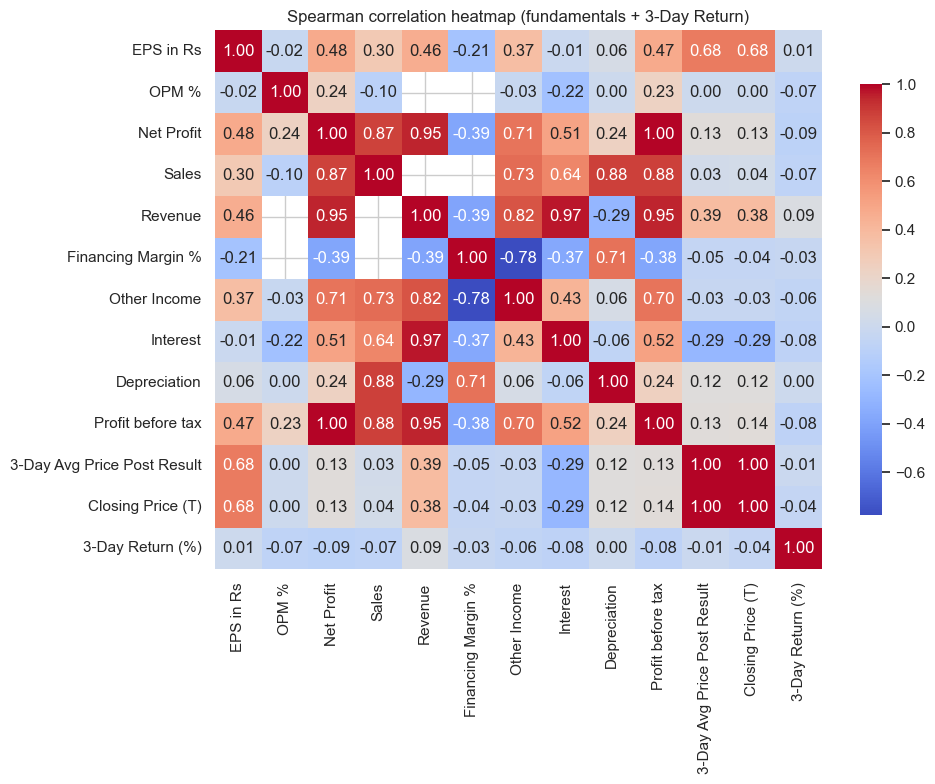

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_7\heatmap_spearman.png
[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_7\tables_cell_7.xlsx


In [16]:
cell_no = 7

RET = "3-Day Return (%)"
LBL = "Movement Label (1,0)"

num_candidates = [
    "EPS in Rs","OPM %","Net Profit","Sales","Revenue","Financing Margin %",
    "Other Income","Interest","Depreciation","Profit before tax",
    "3-Day Avg Price Post Result","Closing Price (T)"
]
num_candidates = [c for c in num_candidates if c in df.columns]

corr_df = []
# Pearson/Spearman with Return
if RET in df.columns:
    for c in num_candidates:
        x = df[c]
        y = df[RET]
        pear = spea = np.nan
        try:
            pear = x.corr(y, method="pearson")
            spea = x.corr(y, method="spearman")
        except Exception:
            pass
        corr_df.append({"feature": c, "pearson_r": pear, "spearman_r": spea})
corr_df = pd.DataFrame(corr_df)
display(corr_df.sort_values("pearson_r", key=lambda s: s.abs(), ascending=False).head(10))

# Point-biserial (or Spearman) with Movement label
pb_rows = []
if LBL in df.columns:
    for c in num_candidates:
        r_pb, p_pb = np.nan, np.nan
        try:
            r_pb, p_pb = pointbiserialr(df[LBL].dropna(), df.loc[df[LBL].dropna().index, c].dropna())
        except Exception:
            pass
        pb_rows.append({"feature": c, "point_biserial_r": r_pb, "p_value": p_pb})
pb_df = pd.DataFrame(pb_rows)
display(pb_df.sort_values("point_biserial_r", key=lambda s: s.abs(), ascending=False).head(10))

# MI with Movement label
mi_tbl = pd.DataFrame()
if LBL in df.columns:
    X = df[num_candidates].copy()
    y = df[LBL].astype("float").copy()
    X = X.apply(lambda s: s.fillna(s.median()), axis=0)
    y = y.fillna(y.mode().iloc[0] if not y.mode().empty else 0).astype(int)
    mi = mutual_info_classif(X, y, random_state=42, discrete_features=False)
    mi_tbl = pd.DataFrame({"feature": num_candidates, "mutual_info": mi}).sort_values("mutual_info", ascending=False)
    display(mi_tbl.head(10))

# Heatmap among numeric fundamentals + Return
heat_cols = [c for c in num_candidates + [RET] if c in df.columns]
if len(heat_cols) >= 3:
    cm = df[heat_cols].corr(method="spearman")
    fig, ax = plt.subplots(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, cbar_kws={"shrink": .8})
    ax.set_title("Spearman correlation heatmap (fundamentals + 3-Day Return)")
    save_fig(fig, cell_no, "heatmap_spearman.png")

save_tables(cell_no, {"corr_with_return": corr_df, "point_biserial": pb_df, "mutual_info": mi_tbl})


# Time & seasonality views

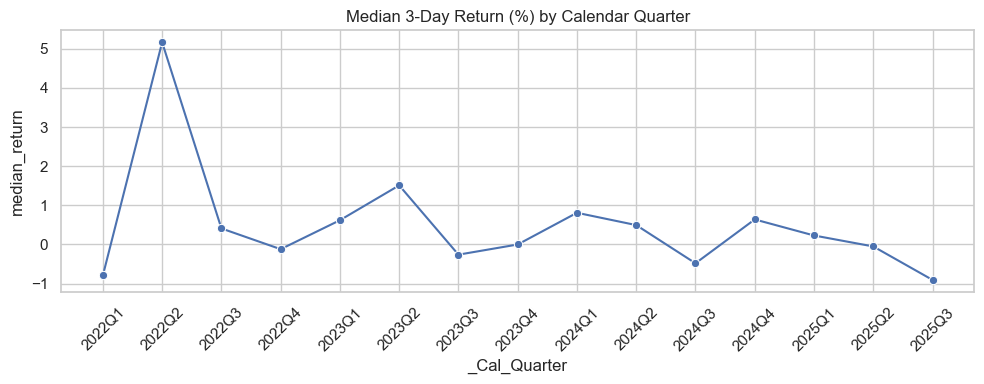

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_8\line_median_return_by_calendar_quarter.png


,_Cal_Quarter,median_return
0,2022Q1,-0.790
1,2022Q2,5.165
2,2022Q3,0.410
3,2022Q4,-0.120
4,2023Q1,0.620


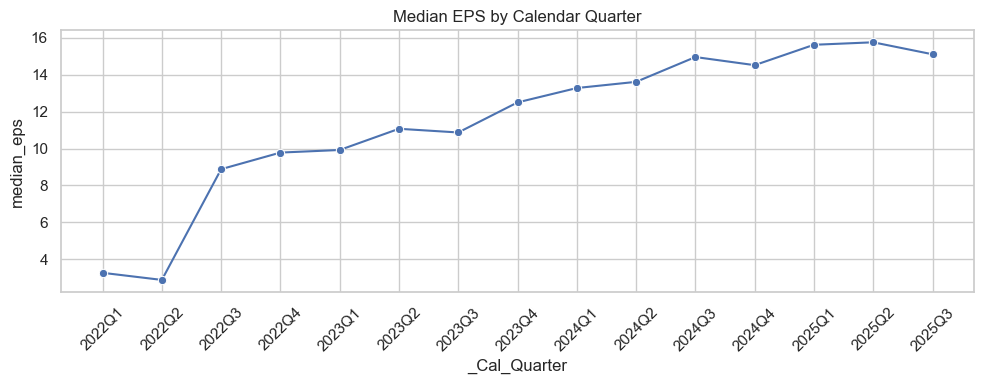

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_8\line_median_eps_by_calendar_quarter.png


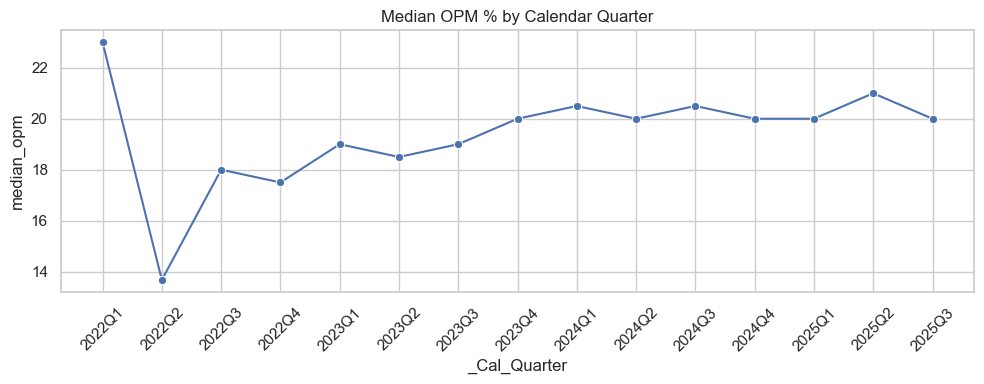

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_8\line_median_opm_by_calendar_quarter.png
[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_8\tables_cell_8.xlsx


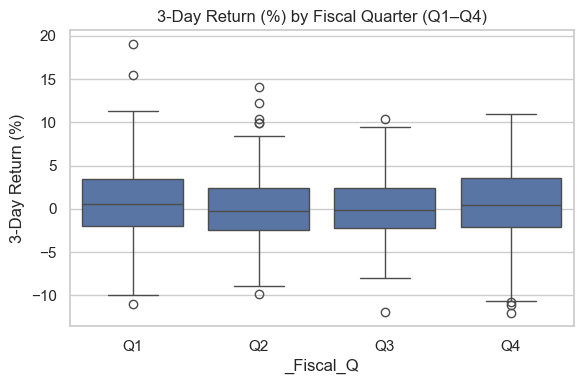

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_8\box_return_by_fiscal_quarter.png


In [10]:
cell_no = 8

RET = "3-Day Return (%)"

# Derive quarter buckets from 'Result Date' if present; else from 'Period' (expects like 'Jun 2024')
def fiscal_quarter(dt):
    if pd.isna(dt):
        return np.nan
    # Indian fiscal year: Apr-Mar; Q1: Apr-Jun, Q2: Jul-Sep, Q3: Oct-Dec, Q4: Jan-Mar
    m = dt.month
    if m in [4,5,6]: return "Q1"
    if m in [7,8,9]: return "Q2"
    if m in [10,11,12]: return "Q3"
    return "Q4"

if "Result Date" in df.columns:
    df["_Fiscal_Q"] = df["Result Date"].apply(fiscal_quarter)
else:
    # Try parsing Period such as 'Jun 2024'
    def infer_dt(per):
        try:
            return pd.to_datetime(per, format="%b %Y")
        except Exception:
            return pd.NaT
    if "Period" in df.columns:
        temp_dt = df["Period"].apply(infer_dt)
        df["_Fiscal_Q"] = temp_dt.apply(fiscal_quarter)

# Median return per calendar quarter (based on actual Result Date quarter)
if "Result Date" in df.columns and RET in df.columns:
    df["_Cal_Quarter"] = df["Result Date"].dt.to_period("Q").astype(str)
    med_ret_by_q = df.groupby("_Cal_Quarter")[RET].median().reset_index().rename(columns={RET:"median_return"})
    fig, ax = plt.subplots(figsize=(10,4))
    sns.lineplot(data=med_ret_by_q, x="_Cal_Quarter", y="median_return", marker="o", ax=ax)
    ax.set_title("Median 3-Day Return (%) by Calendar Quarter")
    ax.tick_params(axis="x", rotation=45)
    save_fig(fig, cell_no, "line_median_return_by_calendar_quarter.png")
    display(med_ret_by_q.head())

# Median EPS/OPM by quarter (calendar quarter)
eps = "EPS in Rs" if "EPS in Rs" in df.columns else None
opm = "OPM %" if "OPM %" in df.columns else None
to_save = {}
if "Result Date" in df.columns:
    if eps:
        t = df.groupby("_Cal_Quarter")[eps].median().reset_index().rename(columns={eps:"median_eps"})
        to_save["median_eps_by_q"] = t
        fig, ax = plt.subplots(figsize=(10,4))
        sns.lineplot(data=t, x="_Cal_Quarter", y="median_eps", marker="o", ax=ax)
        ax.set_title("Median EPS by Calendar Quarter")
        ax.tick_params(axis="x", rotation=45)
        save_fig(fig, cell_no, "line_median_eps_by_calendar_quarter.png")
    if opm:
        t = df.groupby("_Cal_Quarter")[opm].median().reset_index().rename(columns={opm:"median_opm"})
        to_save["median_opm_by_q"] = t
        fig, ax = plt.subplots(figsize=(10,4))
        sns.lineplot(data=t, x="_Cal_Quarter", y="median_opm", marker="o", ax=ax)
        ax.set_title("Median OPM % by Calendar Quarter")
        ax.tick_params(axis="x", rotation=45)
        save_fig(fig, cell_no, "line_median_opm_by_calendar_quarter.png")

if to_save:
    save_tables(cell_no, to_save, book_name="tables_cell_8.xlsx")

# Seasonal boxplot (fiscal quarter)
if "_Fiscal_Q" in df.columns and RET in df.columns:
    fig, ax = plt.subplots(figsize=(6,4))
    sns.boxplot(data=df, x="_Fiscal_Q", y=RET, ax=ax, order=["Q1","Q2","Q3","Q4"])
    ax.set_title("3-Day Return (%) by Fiscal Quarter (Q1–Q4)")
    save_fig(fig, cell_no, "box_return_by_fiscal_quarter.png")


# Cross-plots (relationships)

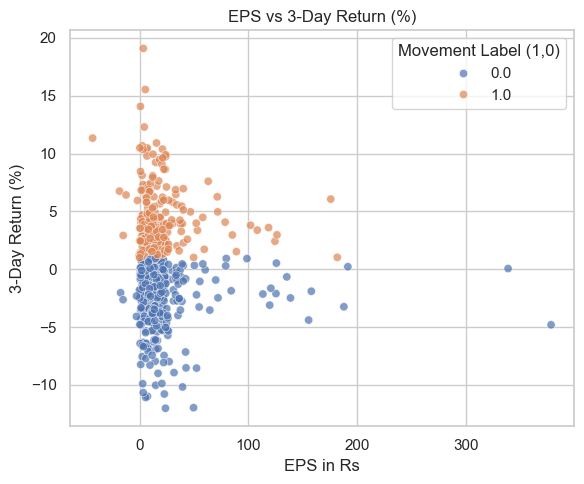

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_9\scatter_eps_vs_return.png


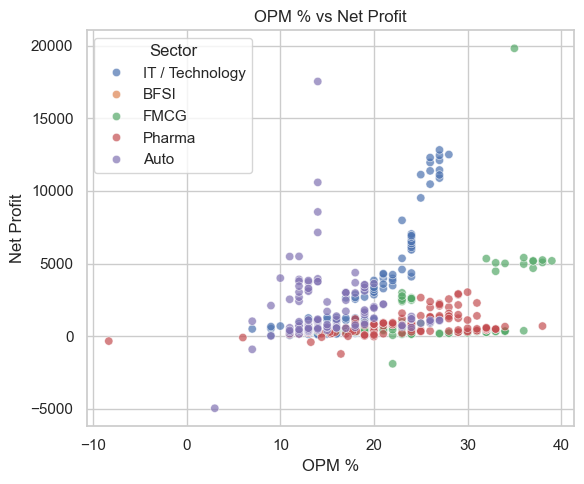

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_9\scatter_opm_vs_netprofit.png


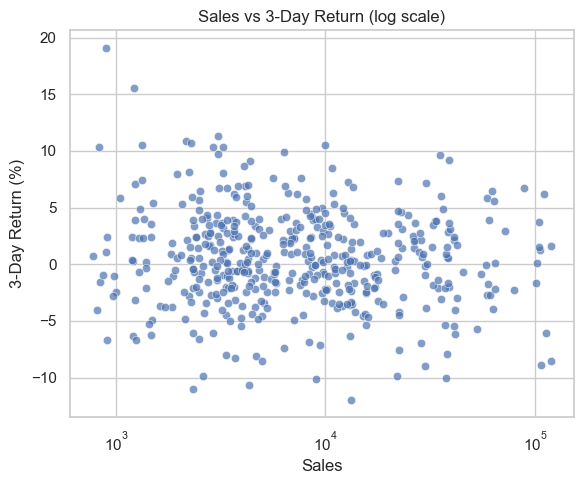

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_9\scatter_sales_vs_return_log.png


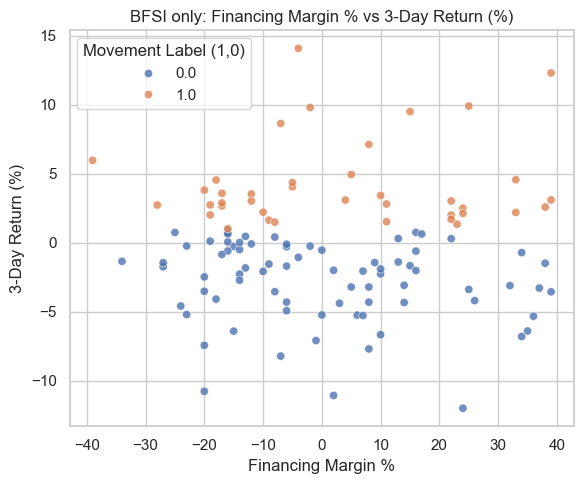

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_9\scatter_bfsi_margin_vs_return.png


In [11]:
cell_no = 9

RET = "3-Day Return (%)"
LBL = "Movement Label (1,0)"

# Scatter: EPS vs Return
if "EPS in Rs" in df.columns and RET in df.columns:
    fig, ax = plt.subplots(figsize=(6,5))
    sns.scatterplot(data=df, x="EPS in Rs", y=RET, hue=LBL if LBL in df.columns else None, ax=ax, alpha=0.7)
    ax.set_title("EPS vs 3-Day Return (%)")
    save_fig(fig, cell_no, "scatter_eps_vs_return.png")

# Scatter: OPM % vs Net Profit (color by Sector)
if "OPM %" in df.columns and "Net Profit" in df.columns:
    fig, ax = plt.subplots(figsize=(6,5))
    hue_col = "Sector" if "Sector" in df.columns else None
    sns.scatterplot(data=df, x="OPM %", y="Net Profit", hue=hue_col, ax=ax, alpha=0.7)
    ax.set_title("OPM % vs Net Profit")
    save_fig(fig, cell_no, "scatter_opm_vs_netprofit.png")

# Scatter: Topline (Sales or Revenue) vs Return (log x)
topline = None
if "Sales" in df.columns:
    topline = "Sales"
elif "Revenue" in df.columns:
    topline = "Revenue"

if topline and RET in df.columns:
    top_ok = df[topline].dropna()
    if (top_ok > 0).any():
        fig, ax = plt.subplots(figsize=(6,5))
        sns.scatterplot(data=df[df[topline] > 0], x=topline, y=RET, ax=ax, alpha=0.7)
        ax.set_xscale("log")
        ax.set_title(f"{topline} vs 3-Day Return (log scale)")
        save_fig(fig, cell_no, f"scatter_{topline.lower()}_vs_return_log.png")

# BFSI: Financing Margin % vs Return
if "Sector" in df.columns and "Financing Margin %" in df.columns and RET in df.columns:
    bfs = df[df["Sector"].str.contains("BFSI", case=False, na=False)]
    if not bfs.empty:
        fig, ax = plt.subplots(figsize=(6,5))
        sns.scatterplot(data=bfs, x="Financing Margin %", y=RET, hue=LBL if LBL in bfs.columns else None, ax=ax, alpha=0.8)
        ax.set_title("BFSI only: Financing Margin % vs 3-Day Return (%)")
        save_fig(fig, cell_no, "scatter_bfsi_margin_vs_return.png")


# Outliers & influence

In [12]:
cell_no = 10

features = ["EPS in Rs","OPM %","3-Day Return (%)","Net Profit","Sales","Revenue"]
features = [c for c in features if c in df.columns]

def zscore(s):
    s = s.astype(float)
    return (s - s.mean()) / s.std(ddof=0)

outlier_tables = {}
for c in features:
    s = df[c].astype(float)
    zs = zscore(s)
    df[f"z_{c}"] = zs
    # Identify outliers with |z| >= 3
    idx = df[zs.abs() >= 3].index
    outlier_tables[f"outliers_{c}"] = df.loc[idx, ["Company","Ticker","Sector","Result Date", c, f"z_{c}"]].sort_values(f"z_{c}", key=lambda s: s.abs(), ascending=False)

# Display one example
for k, v in outlier_tables.items():
    display(v.head(10))
    break

save_tables(cell_no, outlier_tables)
print("✅ Outlier tables saved.")


,Company,Ticker,Sector,Result Date,EPS in Rs,z_EPS in Rs
571,Bosch India,BOSCHLTD,Auto,2025-08-04,378.18,10.730597
564,Bosch India,BOSCHLTD,Auto,2023-11-09,338.68,9.545844
566,Bosch India,BOSCHLTD,Auto,2025-05-24,191.40,5.128365
570,Bosch India,BOSCHLTD,Auto,2025-05-27,187.74,5.018588
568,Bosch India,BOSCHLTD,Auto,2024-11-12,181.70,4.837426
565,Bosch India,BOSCHLTD,Auto,2024-02-13,175.67,4.656564
567,Bosch India,BOSCHLTD,Auto,2024-08-06,157.83,4.121475
569,Bosch India,BOSCHLTD,Auto,2025-01-28,155.36,4.047391
563,Bosch India,BOSCHLTD,Auto,2023-07-31,138.67,3.546795
562,Bosch India,BOSCHLTD,Auto,2023-05-10,135.28,3.445116


[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_10\tables_cell_10.xlsx
✅ Outlier tables saved.


# Sector-specific panels & contrasts

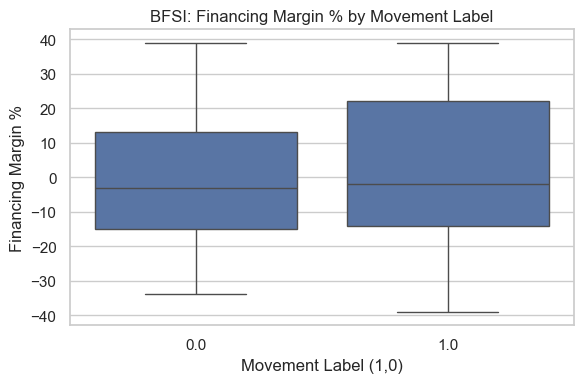

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_11\box_bfsi_margin_by_label.png


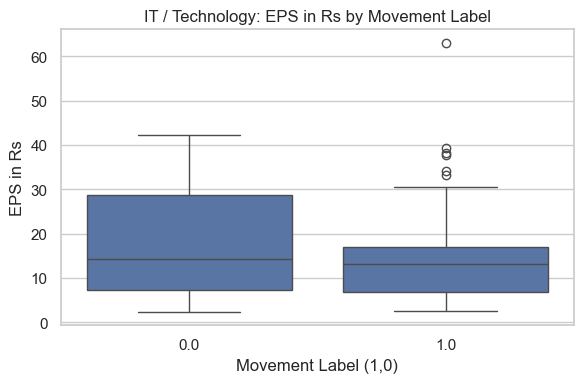

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_11\box_it_technology_EPS_in_Rs_by_label.png


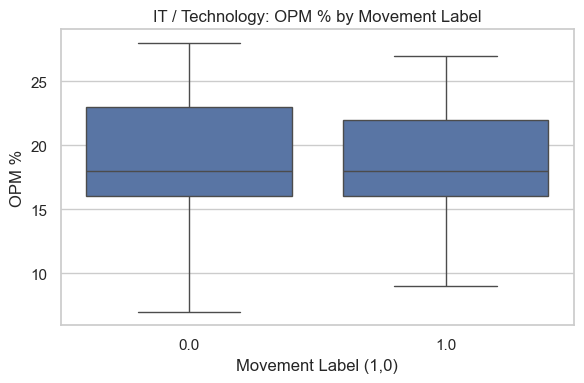

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_11\box_it_technology_OPM_pct_by_label.png


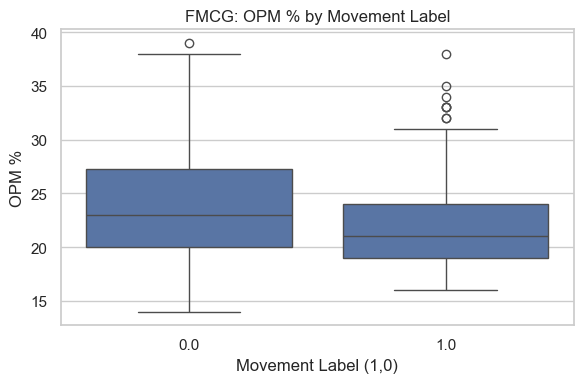

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_11\box_fmcg_OPM_pct_by_label.png


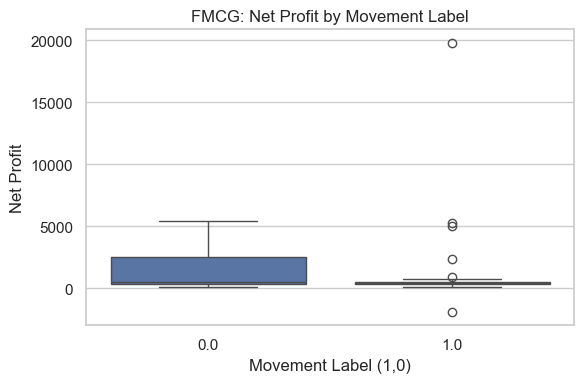

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_11\box_fmcg_Net_Profit_by_label.png


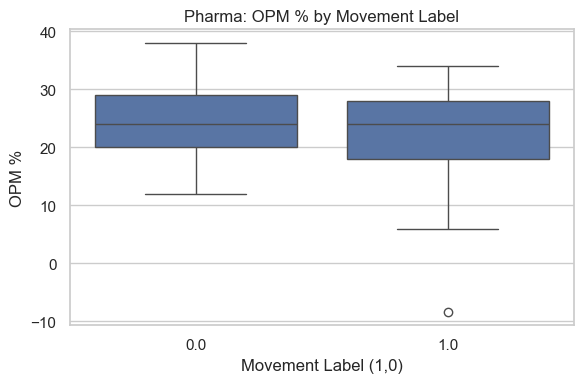

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_11\box_pharma_OPM_pct_by_label.png


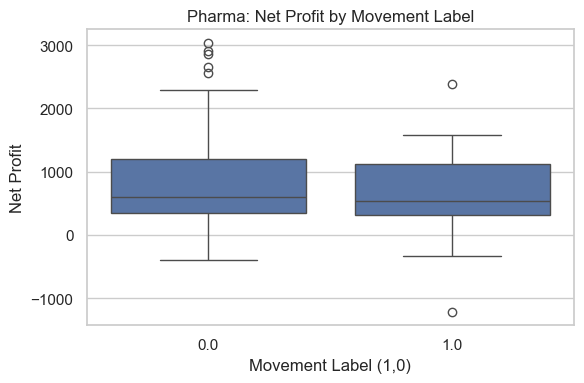

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_11\box_pharma_Net_Profit_by_label.png


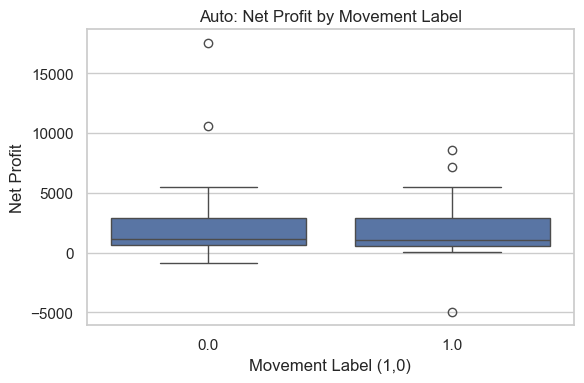

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_11\box_auto_Net_Profit_by_label.png


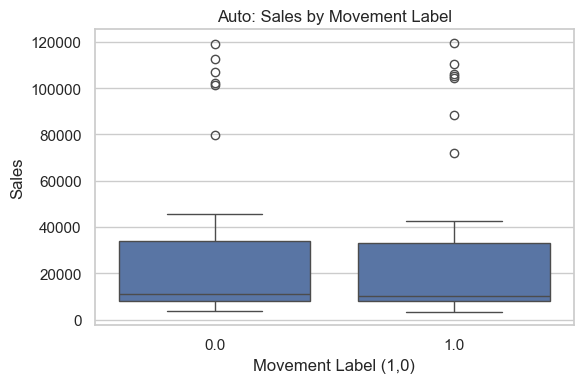

[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_11\box_auto_Sales_by_label.png


In [13]:
cell_no = 11

LBL = "Movement Label (1,0)"
RET = "3-Day Return (%)"

if "Sector" in df.columns:
    # BFSI-specific distributions
    bfs = df[df["Sector"].str.contains("BFSI", case=False, na=False)]
    if not bfs.empty and "Financing Margin %" in bfs.columns:
        fig, ax = plt.subplots(figsize=(6,4))
        sns.boxplot(data=bfs, x=LBL, y="Financing Margin %", ax=ax)
        ax.set_title("BFSI: Financing Margin % by Movement Label")
        save_fig(fig, cell_no, "box_bfsi_margin_by_label.png")

    # IT / FMCG / Pharma / Auto panels (choose a couple of key features)
    panels = {
        "IT / Technology": ["EPS in Rs","OPM %"],
        "FMCG": ["OPM %","Net Profit"],
        "Pharma": ["OPM %","Net Profit"],
        "Auto": ["Net Profit","Sales"] if "Sales" in df.columns else ["Net Profit","Revenue"],
    }
    for sec, feats in panels.items():
        sub = df[df["Sector"] == sec]
        if sub.empty: 
            continue
        for c in feats:
            if c in sub.columns:
                fig, ax = plt.subplots(figsize=(6,4))
                sns.boxplot(data=sub, x=LBL, y=c, ax=ax)
                ax.set_title(f"{sec}: {c} by Movement Label")
                save_fig(fig, cell_no, f"box_{sec.replace(' / ','_').replace(' ','_').lower()}_{c.replace('%','pct').replace(' ','_')}_by_label.png")


# Synthesis tables & “top features” lists

In [14]:
cell_no = 12

RET = "3-Day Return (%)"
LBL = "Movement Label (1,0)"

# 1) Top 10 features by correlation with Return
num_candidates = [
    "EPS in Rs","OPM %","Net Profit","Sales","Revenue",
    "Financing Margin %","Other Income","Interest","Depreciation","Profit before tax",
    "3-Day Avg Price Post Result","Closing Price (T)"
]
num_candidates = [c for c in num_candidates if c in df.columns]

corr_tbl = []
if RET in df.columns:
    for c in num_candidates:
        pear = spea = np.nan
        try:
            pear = df[c].corr(df[RET], method="pearson")
            spea = df[c].corr(df[RET], method="spearman")
        except Exception:
            pass
        corr_tbl.append({"feature": c, "pearson_r": pear, "spearman_r": spea})
corr_tbl = pd.DataFrame(corr_tbl).sort_values("pearson_r", key=lambda s: s.abs(), ascending=False).head(10)

# 2) Top 10 features by mutual information with Movement Label
mi_tbl = pd.DataFrame()
if LBL in df.columns:
    X = df[num_candidates].copy()
    y = df[LBL].copy().astype(float)
    X = X.apply(lambda s: s.fillna(s.median()), axis=0)
    y = y.fillna(y.mode().iloc[0] if not y.mode().empty else 0).astype(int)
    mi = mutual_info_classif(X, y, random_state=42, discrete_features=False)
    mi_tbl = pd.DataFrame({"feature": num_candidates, "mutual_info": mi}).sort_values("mutual_info", ascending=False).head(10)

# 3) Sectors ranked by average Return
sec_rank = pd.DataFrame()
if "Sector" in df.columns and RET in df.columns:
    sec_rank = df.groupby("Sector")[RET].mean().rename("avg_return").reset_index().sort_values("avg_return", ascending=False)

# 4) Cap category summary
cap_sum = pd.DataFrame()
if "Cap Category" in df.columns and RET in df.columns and LBL in df.columns:
    cap_sum = (
        df.groupby("Cap Category")
          .agg(rows=(RET,"size"), mean_return=(RET,"mean"), up_pct=(LBL,"mean"))
          .reset_index()
    )
    cap_sum["up_pct"] = (cap_sum["up_pct"]*100).round(2)

# 5) Significant Up vs Down differences (reuse contrasts from Cell 6 if present)
try:
    contrasts  # from Cell 6
except NameError:
    contrasts = pd.DataFrame()

sig_tbl = pd.DataFrame()
if not contrasts.empty:
    sig_tbl = contrasts[contrasts["t_test_p"] < 0.05].sort_values("cohen_d", key=lambda s: s.abs(), ascending=False)

# Display & save
display(corr_tbl)
display(mi_tbl)
display(sec_rank.head(10))
display(cap_sum)
display(sig_tbl.head(20))

save_tables(cell_no, {
    "top_corr_with_return": corr_tbl,
    "top_mi_with_label": mi_tbl,
    "sector_ranking_by_return": sec_rank,
    "cap_category_summary": cap_sum,
    "significant_up_vs_down": sig_tbl
})


,feature,pearson_r,spearman_r
2,Net Profit,-0.075201,-0.089411
3,Sales,-0.073379,-0.070802
1,OPM %,-0.070920,-0.073488
9,Profit before tax,-0.067342,-0.082060
7,Interest,-0.048199,-0.077030
11,Closing Price (T),-0.045243,-0.044906
0,EPS in Rs,-0.037308,0.005594
6,Other Income,-0.033754,-0.058332
8,Depreciation,-0.031937,0.003572
4,Revenue,0.022762,0.089819


,feature,mutual_info
5,Financing Margin %,0.022104
3,Sales,0.021613
4,Revenue,0.015852
6,Other Income,0.011731
8,Depreciation,0.010469
1,OPM %,0.006383
10,3-Day Avg Price Post Result,0.005908
11,Closing Price (T),0.000376
2,Net Profit,0.000000
0,EPS in Rs,0.000000


,Sector,avg_return
0,Auto,0.912845
4,Pharma,0.501966
3,IT / Technology,0.311282
2,FMCG,0.211453
1,BFSI,-0.464444


,Cap Category,rows,mean_return,up_pct
0,Large,195,-0.074462,36.41
1,Mid,182,0.312527,41.76
2,Small,208,0.623575,44.93


,feature,mean_up,mean_down,median_up,median_down,cohen_d,cliffs_delta,t_test_p,mannwhitney_p
8,3-Day Return (%),4.206833,-2.436628,3.435,-1.86,2.407283,1.000000,2.804010e-106,4.493725e-94
1,OPM %,19.784577,21.019511,19.000,20.00,-0.188270,-0.096978,4.511819e-02,7.226466e-02
2,Net Profit,2353.132208,3044.392006,813.500,1019.50,-0.162659,-0.107449,4.770516e-02,2.705937e-02


[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_12\tables_cell_12.xlsx


# Skewness & transform suggestions

In [15]:
cell_no = 13

cands = ["EPS in Rs","Net Profit","Sales","Revenue","Other Income","Interest","Depreciation",
         "3-Day Avg Price Post Result","Closing Price (T)"]
cands = [c for c in cands if c in df.columns]

rows = []
for c in cands:
    s = pd.to_numeric(df[c], errors="coerce").dropna()
    if s.empty:
        rows.append({"feature": c, "skewness": np.nan, "suggestion": "insufficient data"})
        continue
    sk = skew(s)
    suggestion = "no change"
    if sk > 0.75:
        if (s > 0).all():
            suggestion = "log1p transform recommended"
        else:
            suggestion = "winsorize/top-code high tail"
    elif sk < -0.75:
        suggestion = "consider symmetric scaling or winsorize low tail"
    rows.append({"feature": c, "skewness": sk, "suggestion": suggestion})

sk_tbl = pd.DataFrame(rows).sort_values("skewness", ascending=False)
display(sk_tbl)

save_tables(cell_no, {"skewness_suggestions": sk_tbl})


,feature,skewness,suggestion
0,EPS in Rs,5.321150,winsorize/top-code high tail
6,Depreciation,5.199870,winsorize/top-code high tail
5,Interest,4.543636,winsorize/top-code high tail
8,Closing Price (T),4.278727,log1p transform recommended
7,3-Day Avg Price Post Result,4.195265,log1p transform recommended
4,Other Income,4.037141,winsorize/top-code high tail
2,Sales,2.985166,log1p transform recommended
1,Net Profit,2.420606,winsorize/top-code high tail
3,Revenue,1.404346,log1p transform recommended


[saved] C:\Users\cecme\Walsh\MS Capstone\Walsh-MS_CapstoneProject\src\notebooks\Data_Cleaners_EDA\cell_13\tables_cell_13.xlsx
